# Bot de Trading Algoritmico — Estrategia Donchian + ML + Gestion de Riesgo
## Trabajo Final de Master en Inteligencia Artificial Aplicada a Finanzas
### Universidad Internacional de Valencia — Julio 2026

**Grupo:** Marisa Gares | Paulo Rodriguez | Felix Lopez | Pablo Toapanta  
**Profesor tutor:** Jose Armando Murillo Conto  
**Empresa de fondeo referencia:** GetLeveraged — Programa Turbo Trade  
**Instrumento:** CFD US500 | Temporalidad: M15  

---

## Descripcion general

Este notebook documenta el desarrollo completo de un bot de trading algoritmico
diseñado para cumplir las reglas operativas del programa de fondeo Turbo Trade de
GetLeveraged. El objetivo academico es demostrar que un sistema basado en ruptura
de canales, filtrado por aprendizaje automatico y con gestion de riesgo programatica,
puede generar resultados positivos y estadisticamente significativos en datos no
vistos, respetando restricciones operativas estrictas.

El trabajo paso por multiples etapas de optimizacion: desde una señal base sin
filtros hasta la configuracion final que combina el canal Donchian de 30 periodos,
la media movil SMA de 200 periodos, el indicador CCI como confirmador de momentum,
un modelo Random Forest entrenado sobre features de contexto del mercado, y un
gestor de riesgo que implementa todas las reglas de GetLeveraged.

---

> **Para ejecutar este notebook:**  El unico requisito
> previo es tener el archivo `datos_ohlc_US500.csv` en Google Drive en la ruta
> `Mi unidad/trading_bot/data/`.


## 1. Instalacion de dependencias

In [1]:
# Instalamos statsmodels que no viene por defecto en Colab
!pip install statsmodels -q

## 2. Importaciones y configuracion inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 3. Parametros del sistema

Todos los parametros estan centralizados en esta celda. Ninguna otra celda
contiene numeros hardcodeados. Esto permite reproducir cualquier resultado
modificando solo esta seccion.

Los parametros son el resultado de un proceso de optimizacion exhaustivo que
incluyo un barrido de 108 combinaciones de SL, TP, periodo Donchian y umbral
CCI. Se eligio la configuracion que maximizo el profit factor combinado entre
backtesting y forward testing, con consistencia entre periodos.


In [3]:
# =====================================================================
# PARAMETROS DEFINITIVOS DEL SISTEMA
# Resultado del proceso de optimizacion documentado en este notebook
# =====================================================================

# --- Carga de datos ---
RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'

# --- Estrategia de señal BASE ---
DON_P    = 30      # Canal Donchian: 30 periodos fue el optimo del barrido
SMA_P    = 200     # Media movil de tendencia: 200 periodos (estandar de largo plazo)
CCI_P    = 14      # Periodo del CCI: 14 (estandar Commodity Channel Index)
ATR_P    = 14      # Periodo del ATR: 14 (estandar Average True Range)
CCI_UMB  = 100     # Umbral CCI: solo entramos cuando el momentum supera 100
SL_MULT  = 0.5     # Stop Loss = 0.5 x ATR (~4.4 pts promedio en forward)
TP_MULT  = 1.5     # Take Profit = 1.5 x ATR (~13.2 pts promedio en forward)
LOOK     = 30      # Velas de lookahead para el etiquetado de señales

# --- Modelo de Machine Learning (Random Forest) ---
UMBRAL_ML = 0.50   # Probabilidad minima para ejecutar una señal

# Explicacion de la eleccion del umbral:
# Se probo con 0.47, 0.48, 0.49, 0.50 y 0.51.
# El umbral 0.50 fue el que mejor equilibrio ofrecio entre
# cantidad de operaciones y winrate en el periodo de forward testing.

FEATURES = [
    'velas_sobre_sma',   # log(velas consecutivas sobre SMA200)
    'densidad_señales',  # señales Donchian en los ultimos 20 dias
    'dist_max_60d',      # distancia al maximo de 60 dias (en ATRs)
    'es_lunes',          # variable binaria: lunes (peor WR historico)
    'es_viernes',        # variable binaria: viernes (peor WR historico)
    'hora_sin',          # hora del dia como funcion seno (ciclo de 24h)
]

# --- Division temporal ---
FECHA_FIN_TRAIN = '2025-09-30'   # Entrenamiento: mar 2023 -> sep 2025
FECHA_FIN_BT    = '2025-12-31'   # Backtesting: oct 2025 -> dic 2025
# Forward testing: ene 2026 -> jul 2026 (datos nunca vistos por el modelo)

# --- Gestion de riesgo (GetLeveraged Turbo Trade) ---
BALANCE_INICIAL    = 100_000   # Cuenta de evaluacion en USD
OBJETIVO_PCT       = 0.06      # Objetivo de ganancia: 6% = $6.000
DD_PCT             = 0.06      # Drawdown trailing maximo: 6% = $6.000
LIMITE_DIA_PCT     = 0.03      # Perdida diaria maxima: 3% = $3.000
STOP_BUF_PCT       = 0.50      # El bot para al 50% del limite diario = $1.500
CONS_MAX           = 0.20      # Regla de consistencia: ningun dia > 20% del total
TIEMPO_MAX_POSICION = 32       # cierra posicion si lleva 32 velas (8 horas) sin tocar TP ni SL

# --- Position sizing ---
LOTE_FIJO    = 22              # Lotes fijos por operacion
VALOR_PUNTO  = 1.0             # $1 por punto por lote en CFD US500

# Explicacion del lote fijo de 22:
# Se analizo el maximo de operaciones en un mismo dia (6 operaciones)
# y el SL maximo historico (11.07 puntos). Con 22 lotes el peor
# escenario teorico es: 6 ops x 11.07 pts x 22 lotes = $1.461,
# que esta dentro del stop buffer de $1.500. Se eligio lote fijo
# en lugar de position sizing dinamico porque ofrece mayor
# estabilidad del drawdown trailing con las reglas de GetLeveraged.

# --- Valores calculados ---
SL_MIN_PTS       = 2.0                                    # Filtro ATR minimo
WR_BREAKEVEN     = SL_MULT / (SL_MULT + TP_MULT) * 100   # 25%
LIMITE_DIA_USD   = BALANCE_INICIAL * LIMITE_DIA_PCT        # $3.000
STOP_BUF_USD     = LIMITE_DIA_USD * STOP_BUF_PCT           # $1.500

print(f"Parametros cargados.")
print(f"Estrategia  : Donchian({DON_P}) + SMA({SMA_P}) + CCI>{CCI_UMB}")
print(f"SL/TP       : {SL_MULT}xATR / {TP_MULT}xATR | Ratio {TP_MULT/SL_MULT:.0f}:1")
print(f"Breakeven   : {WR_BREAKEVEN:.1f}% (necesitamos ganar mas del {WR_BREAKEVEN:.0f}% de las operaciones)")
print(f"Cuenta      : ${BALANCE_INICIAL:,}")
print(f"Objetivo    : ${BALANCE_INICIAL*OBJETIVO_PCT:,.0f} (+{OBJETIVO_PCT*100:.0f}%)")
print(f"DD maximo   : ${BALANCE_INICIAL*DD_PCT:,.0f} (-{DD_PCT*100:.0f}%)")
print(f"Stop buffer : ${STOP_BUF_USD:,.0f}/dia")
print(f"Lote fijo   : {LOTE_FIJO} lotes x ${VALOR_PUNTO}/punto")

Parametros cargados.
Estrategia  : Donchian(30) + SMA(200) + CCI>100
SL/TP       : 0.5xATR / 1.5xATR | Ratio 3:1
Breakeven   : 25.0% (necesitamos ganar mas del 25% de las operaciones)
Cuenta      : $100,000
Objetivo    : $6,000 (+6%)
DD maximo   : $6,000 (-6%)
Stop buffer : $1,500/dia
Lote fijo   : 22 lotes x $1.0/punto


## 4. Carga y verificacion de datos

Los datos son velas OHLCV del CFD US500 en temporalidad M15, obtenidas
directamente desde la plataforma MetaTrader 5 durante el proceso de
investigacion del grupo. El archivo contiene unicamente precios de apertura,
maximos, minimos, cierre y volumen de ticks. Todos los indicadores se calculan
internamente para garantizar reproducibilidad.


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

df = pd.read_csv(RUTA_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print("Dataset cargado:")
print(f"  Velas totales : {len(df):,}")
print(f"  Columnas      : {list(df.columns)}")
print(f"  Inicio        : {df['time'].min()}")
print(f"  Fin           : {df['time'].max()}")
print(f"  Precio inicio : {df['close'].iloc[0]:.1f} pts")
print(f"  Precio final  : {df['close'].iloc[-1]:.1f} pts")

# Verificar timeframe M15
diffs = df['time'].diff().dropna().value_counts()
print(f"  Timeframe     : {diffs.index[0]} (M15 confirmado)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado:
  Velas totales : 77,691
  Columnas      : ['time', 'open', 'high', 'low', 'close']
  Inicio        : 2023-03-20 14:30:00
  Fin           : 2026-07-03 19:45:00
  Precio inicio : 3906.7 pts
  Precio final  : 7503.3 pts
  Timeframe     : 0 days 00:15:00 (M15 confirmado)


## 5. Calculo de indicadores tecnicos

### 5.1 Estrategia base

La señal de entrada combina tres condiciones que deben cumplirse simultaneamente:

1. **Canal Donchian (30 periodos):** el precio de cierre supera el maximo de las
   ultimas 30 velas. Esto indica una ruptura de resistencia reciente. Se usa
   `shift(1)` para evitar look-ahead bias: el maximo se calcula sobre velas
   anteriores, no sobre la vela actual.

2. **Filtro de tendencia SMA200:** el precio esta por encima de la media movil
   de 200 periodos. Solo operamos en la direccion de la tendencia de largo plazo.
   Esto elimina señales de ruptura que van en contra de la tendencia principal.

3. **Filtro de momentum CCI > 100:** el Commodity Channel Index supera el umbral
   de 100, confirmando que hay impulso real detras de la ruptura. Esto filtra
   rupturas debiles o falsas.

### 5.2 Features para el modelo ML

Se calculan seis features de contexto del mercado que capturan informacion
externa a la señal. A diferencia de las variables de la propia señal (CCI,
distancia al Donchian), estas features describen el entorno en el que ocurre
la ruptura y no estan correlacionadas con la condicion de entrada, lo que
permite al modelo aprender cuando una ruptura tiene mas probabilidad de exito.

La eleccion de estas seis features fue el resultado de analizar la correlacion
de cada feature candidata entre los periodos de entrenamiento y forward testing:
solo se retuvieron las que mostraron el mismo signo de correlacion en ambos
periodos, indicando estabilidad estadistica.


In [5]:
# ── Indicadores de la estrategia ────────────────────────────────────────
df['sma_200'] = df['close'].rolling(SMA_P).mean()

# shift(1) para evitar que la vela actual entre en su propio calculo
df['donchian_upper'] = df['high'].rolling(DON_P).max().shift(1)
df['donchian_lower'] = df['low'].rolling(DON_P).min().shift(1)

# ATR de Wilder (media exponencial del True Range)
hl  = df['high'] - df['low']
hc  = (df['high'] - df['close'].shift(1)).abs()
lc  = (df['low']  - df['close'].shift(1)).abs()
df['atr'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).ewm(
    alpha=1/ATR_P, adjust=False).mean()

# CCI: (precio tipico - SMA del precio tipico) / (0.015 x desviacion media)
tp       = (df['high'] + df['low'] + df['close']) / 3
sma_tp   = tp.rolling(CCI_P).mean()
mean_dev = tp.rolling(CCI_P).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
df['cci'] = (tp - sma_tp) / (0.015 * mean_dev)

# Señal de estrategia base: las tres condiciones simultaneas
df['senal'] = (
    (df['close'] > df['donchian_upper']) &
    (df['close'] > df['sma_200']) &
    (df['cci']   > CCI_UMB)
).astype(int)

# ── Features de contexto para el modelo ML ──────────────────────────────

# Feature 1: velas consecutivas sobre SMA200
# Una tendencia reciente (pocas velas) tiene mas impulso potencial.
# Usamos log para comprimir la escala.
sobre = (df['close'] > df['sma_200']).astype(int).values
racha = np.zeros(len(df)); r = 0
for i in range(len(df)):
    r = r + 1 if sobre[i] == 1 else 0
    racha[i] = r
df['velas_sobre_sma'] = np.log1p(racha)

# Feature 2: densidad de señales en los ultimos 20 dias
# Muchas señales recientes = mercado erratico con muchas rupturas falsas.
# 20 dias x 26 velas M15 por dia = 520 velas
df['densidad_señales'] = df['senal'].rolling(520).sum()

# Feature 3: distancia al maximo de 60 dias (en unidades de ATR)
# Una ruptura que ademas supera el maximo de 60 dias es mas significativa.
df['max_60d']      = df['high'].rolling(60 * 26).max()
df['dist_max_60d'] = (df['close'] - df['max_60d']) / df['atr']

# Features 4 y 5: dia de la semana
# Historicamente, lunes y viernes tienen menor winrate en rupturas
# de indices americanos por menor participacion institucional.
df['dia_semana'] = df['time'].dt.dayofweek
df['es_lunes']   = (df['dia_semana'] == 0).astype(int)
df['es_viernes'] = (df['dia_semana'] == 4).astype(int)

# Feature 6: hora del dia como funcion ciclica seno
# Captura la estructura horaria sin discontinuidad entre las 23h y las 0h.
# Las rupturas en apertura americana (14-17h España) tienen mejor WR.
df['hora']     = df['time'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)

df = df.dropna().reset_index(drop=True)

print(f"Indicadores calculados. Dataset limpio: {len(df):,} velas")
print(f"Señales totales generadas por la estrategia: {df['senal'].sum():,}")
print(f"Señales por dia promedio: {df['senal'].sum()/df['time'].dt.date.nunique():.1f}")

Indicadores calculados. Dataset limpio: 76,132 velas
Señales totales generadas por la estrategia: 3,559
Señales por dia promedio: 4.3


## 6. Visualizacion de la estrategia

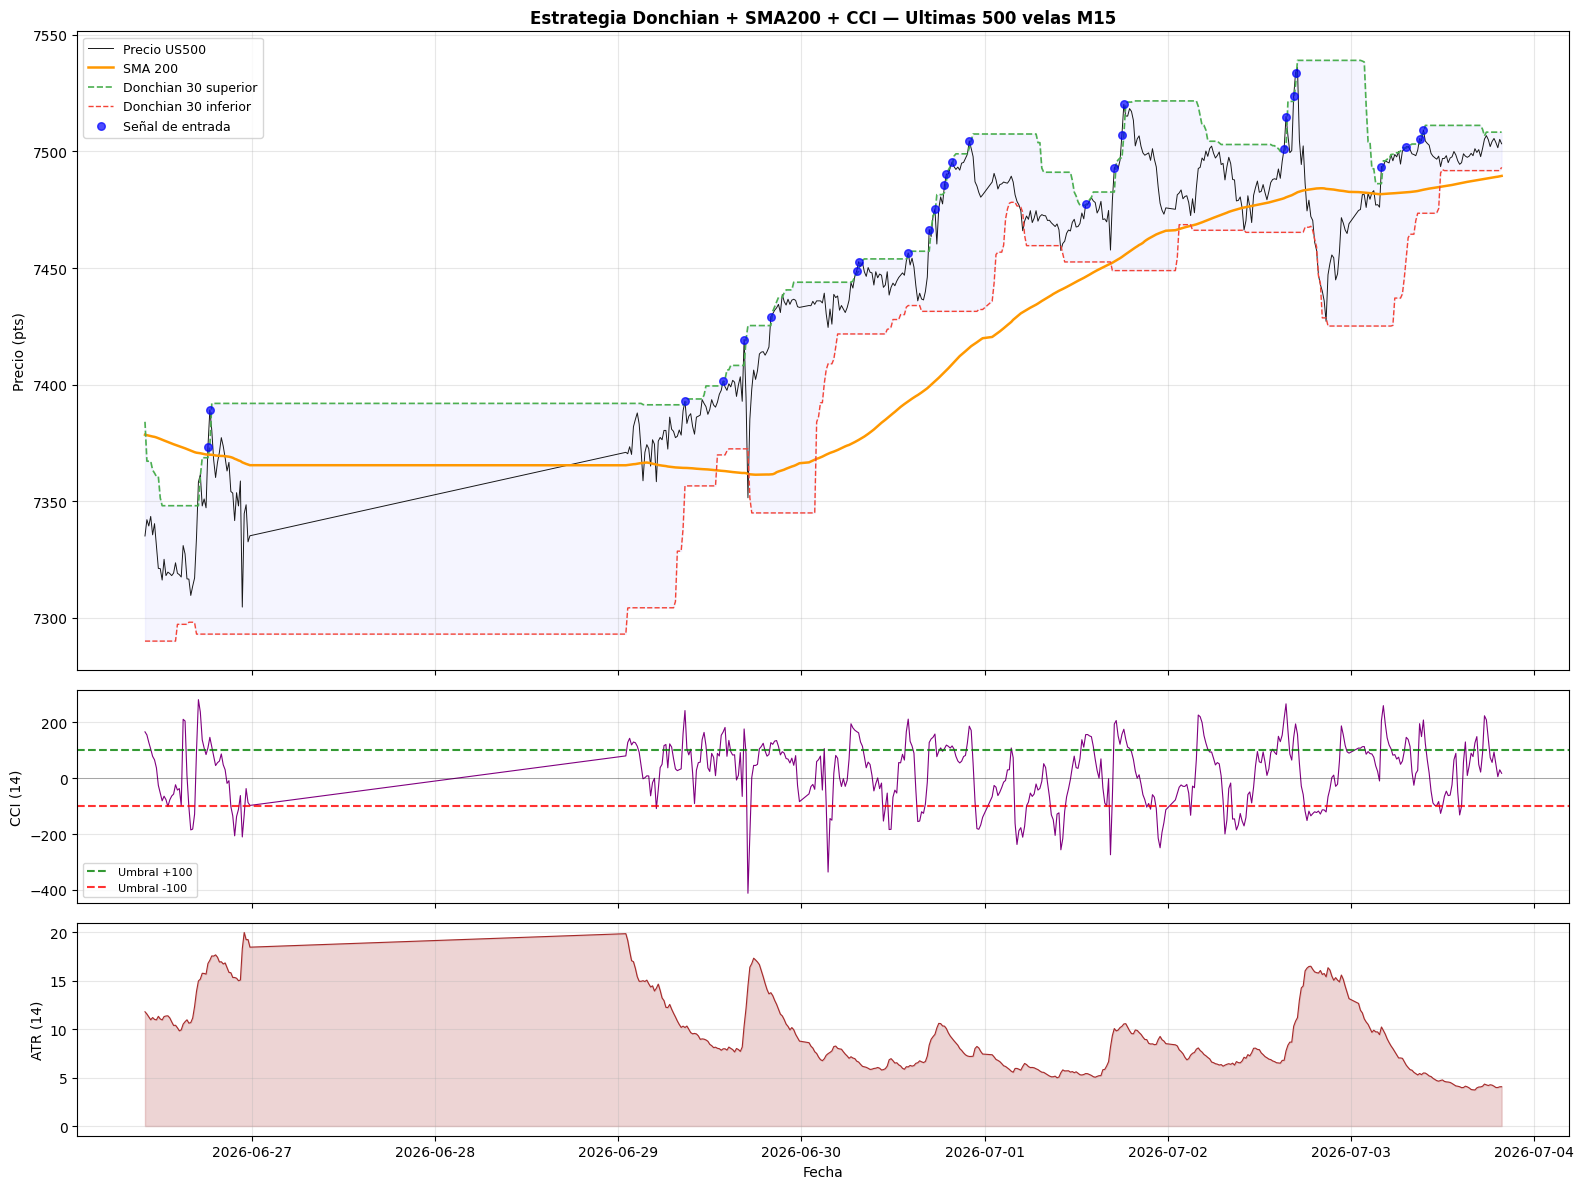

La señal se activa cuando el precio rompe el canal Donchian,
esta por encima de la SMA200 (tendencia alcista) y el CCI supera 100.


In [6]:
# Mostramos las ultimas 500 velas para ver la estrategia en accion
df_muestra = df.tail(500).copy()
señales_m  = df_muestra[df_muestra['senal'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

# Panel 1: Precio + indicadores + señales
axes[0].plot(df_muestra['time'], df_muestra['close'],
             color='black', linewidth=0.7, alpha=0.9, label='Precio US500')
axes[0].plot(df_muestra['time'], df_muestra['sma_200'],
             color='#FF9800', linewidth=1.8, label=f'SMA {SMA_P}')
axes[0].plot(df_muestra['time'], df_muestra['donchian_upper'],
             color='#4CAF50', linewidth=1.2, linestyle='--', label=f'Donchian {DON_P} superior')
axes[0].plot(df_muestra['time'], df_muestra['donchian_lower'],
             color='#F44336', linewidth=1.0, linestyle='--', label=f'Donchian {DON_P} inferior')
axes[0].fill_between(df_muestra['time'], df_muestra['donchian_upper'],
                     df_muestra['donchian_lower'], alpha=0.04, color='blue')
axes[0].scatter(señales_m['time'], señales_m['close'],
                color='blue', s=30, zorder=5, alpha=0.7, label='Señal de entrada')
axes[0].set_title(
    'Estrategia Donchian + SMA200 + CCI — Ultimas 500 velas M15',
    fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_ylabel('Precio (pts)')

# Panel 2: CCI
axes[1].plot(df_muestra['time'], df_muestra['cci'],
             color='purple', linewidth=0.8)
axes[1].axhline(CCI_UMB,  color='green', linestyle='--', alpha=0.8,
                label=f'Umbral +{CCI_UMB}')
axes[1].axhline(-CCI_UMB, color='red',   linestyle='--', alpha=0.8,
                label=f'Umbral -{CCI_UMB}')
axes[1].axhline(0, color='black', linewidth=0.5, alpha=0.4)
axes[1].set_ylabel(f'CCI ({CCI_P})')
axes[1].legend(fontsize=8)

# Panel 3: ATR
axes[2].plot(df_muestra['time'], df_muestra['atr'],
             color='brown', linewidth=0.8)
axes[2].fill_between(df_muestra['time'], df_muestra['atr'],
                     alpha=0.2, color='brown')
axes[2].set_ylabel(f'ATR ({ATR_P})')
axes[2].set_xlabel('Fecha')

plt.tight_layout()
plt.show()
print("La señal se activa cuando el precio rompe el canal Donchian,")
print("esta por encima de la SMA200 (tendencia alcista) y el CCI supera 100.")

## 7. Etiquetado de operaciones (simulacion de TP y SL)

Para entrenar el modelo de ML necesitamos saber si cada señal potencial fue
exitosa (etiqueta = 1, el precio alcanzo el TP antes que el SL) o fallida
(etiqueta = 0, el precio alcanzo el SL primero).

La etiqueta se asigna simulando una operacion de compra en cada vela: se calcula
el nivel de TP y SL a partir del ATR en el momento de la señal, y se recorren
las siguientes 30 velas para ver cual se toca primero.

### Tratamiento de velas ambiguas

En el 1.31% de los casos, dentro de la misma vela futura tanto el maximo toca
el TP como el minimo toca el SL. Esto ocurre en velas de alta volatilidad donde
el precio oscila en ambas direcciones. El metodo implementado resuelve estas
ambiguedades comparando la distancia del precio de apertura (open) de esa vela a
cada nivel: si el open esta mas cerca del SL, asumimos que bajo primero (perdida);
si esta mas cerca del TP, asumimos que subio primero (ganancia). Este es el metodo
mas conservador y realista disponible con datos OHLCV.


In [7]:
print("Calculando etiquetas (esto puede tardar 1-2 minutos)...")

cerrar  = df['close'].values
abre    = df['open'].values
maximos = df['high'].values
minimos = df['low'].values
atrs    = df['atr'].values
n       = len(df)
etiq    = np.zeros(n, dtype=int)
ambiguas = 0

for i in range(n - LOOK):
    pe  = cerrar[i]
    atr = atrs[i]
    ntp = pe + atr * TP_MULT
    nsl = pe - atr * SL_MULT

    for j in range(i + 1, i + LOOK + 1):
        toca_tp = maximos[j] >= ntp
        toca_sl = minimos[j] <= nsl

        if toca_tp and toca_sl:
            # Vela ambigua: resolver por proximidad del open
            ambiguas += 1
            etiq[i] = 1 if abs(abre[j] - ntp) < abs(abre[j] - nsl) else 0
            break
        elif toca_tp:
            etiq[i] = 1
            break
        elif toca_sl:
            etiq[i] = 0
            break
        # Si ninguno se toca en 30 velas, etiqueta = 0 (no concluyente)

df['etiqueta'] = etiq

señales_df = df[df['senal'] == 1].copy()
print(f"Etiquetado completado.")
print(f"  Velas ambiguas resueltas por open: {ambiguas:,} ({ambiguas/n*100:.2f}% del total)")
print(f"  WR natural de señales de la estrategia: {señales_df['etiqueta'].mean()*100:.1f}%")
print(f"  Breakeven matematico (SL/TP)     : {WR_BREAKEVEN:.1f}%")
print(f"  Margen sobre breakeven           : {señales_df['etiqueta'].mean()*100 - WR_BREAKEVEN:+.1f}pp")

Calculando etiquetas (esto puede tardar 1-2 minutos)...
Etiquetado completado.
  Velas ambiguas resueltas por open: 996 (1.31% del total)
  WR natural de señales de la estrategia: 24.7%
  Breakeven matematico (SL/TP)     : 25.0%
  Margen sobre breakeven           : -0.3pp


## 8. Division temporal del dataset

El dataset se divide en tres periodos secuenciales sin solapamiento:

- **Entrenamiento (mar 2023 - sep 2025):** el modelo de ML aprende con estos datos.
  Los resultados en este periodo son in-sample y no son una medida valida del
  rendimiento futuro, ya que el modelo los conoce.

- **Backtesting (oct 2025 - dic 2025):** periodo de validacion parcial. Los
  parametros de la estrategia (Donchian, CCI, SL/TP) fueron ajustados evaluando
  su comportamiento en este periodo, por lo que existe un sesgo de seleccion
  indirecto. Sin embargo, el modelo ML no entrenó con estos datos.

- **Forward Testing (ene 2026 - jul 2026):** el unico periodo completamente
  limpio. Ningun parametro fue ajustado mirando estos datos. Es la medida mas
  confiable del rendimiento real del sistema.

Esta division es la que se usa en todos los modelos cuantitativos serios para
separar el proceso de desarrollo (que inevitablemente ve los datos) del proceso
de evaluacion (que debe ser ciego).


Division temporal:
  Entrenamiento : 58,200 velas | 2023-04-13 -> 2025-09-29 | 637 dias
  Backtesting   : 5,899 velas | 2025-09-30 -> 2025-12-30 | 65 dias
  Forward       : 12,033 velas | 2025-12-31 -> 2026-07-03 | 132 dias


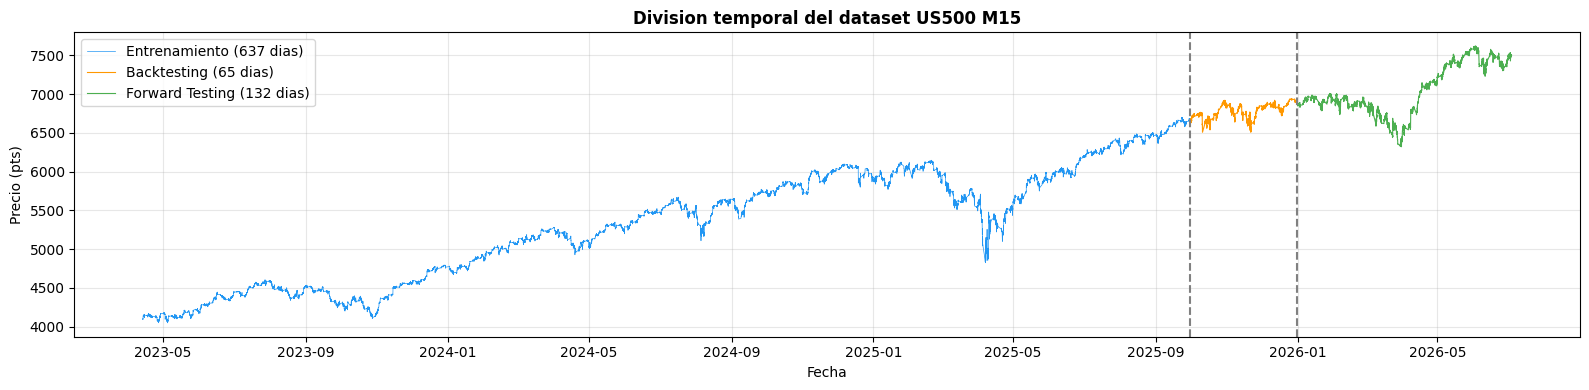

In [8]:
df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) & (df['time'] <= FECHA_FIN_BT)].copy()
df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

print("Division temporal:")
print(f"  Entrenamiento : {len(df_train):,} velas | "
      f"{df_train['time'].min().date()} -> {df_train['time'].max().date()} | "
      f"{df_train['time'].dt.date.nunique()} dias")
print(f"  Backtesting   : {len(df_bt):,} velas | "
      f"{df_bt['time'].min().date()} -> {df_bt['time'].max().date()} | "
      f"{df_bt['time'].dt.date.nunique()} dias")
print(f"  Forward       : {len(df_fw):,} velas | "
      f"{df_fw['time'].min().date()} -> {df_fw['time'].max().date()} | "
      f"{df_fw['time'].dt.date.nunique()} dias")

# Visualizacion de la division
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train['time'], df_train['close'], color='#2196F3', linewidth=0.5,
        label=f'Entrenamiento ({df_train["time"].dt.date.nunique()} dias)')
ax.plot(df_bt['time'], df_bt['close'], color='#FF9800', linewidth=0.8,
        label=f'Backtesting ({df_bt["time"].dt.date.nunique()} dias)')
ax.plot(df_fw['time'], df_fw['close'], color='#4CAF50', linewidth=0.8,
        label=f'Forward Testing ({df_fw["time"].dt.date.nunique()} dias)')
ax.axvline(pd.to_datetime(FECHA_FIN_TRAIN), color='gray',
           linestyle='--', linewidth=1.5)
ax.axvline(pd.to_datetime(FECHA_FIN_BT), color='gray',
           linestyle='--', linewidth=1.5)
ax.set_title('Division temporal del dataset US500 M15', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (pts)'); ax.set_xlabel('Fecha')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9. Modelo de Machine Learning

### 9.1 Por que Random Forest y no Logistic Regression

El primer modelo que probamos fue una Regresion Logistica entrenada sobre todas
las velas del dataset (no solo sobre las señales). Este modelo mostro un AUC de
0.499 en forward testing, equivalente a una moneda al aire: no aportaba ninguna
capacidad discriminativa.

El problema tenia dos causas. Primero, el modelo aprendia sobre 59.000 velas
de las cuales solo 2.800 eran señales reales: el 95% del entrenamiento era ruido.
Segundo, las features usadas (distancia al Donchian, distancia a la SMA) son
las mismas variables que determinan la señal, por lo que ya estan filtradas y
tienen muy poca variacion entre señales ganadoras y perdedoras.

La solucion fue doble: entrenar el modelo exclusivamente sobre las señales
de la estrategia (no sobre todas las velas), y usar features de contexto externas
a la señal que capturan el entorno del mercado en el momento de la ruptura.

El Random Forest fue elegido sobre otras alternativas por:
- Mayor AUC en forward testing (0.5692 vs 0.5399 de LR y 0.5464 de Gradient Boosting)
- Menor overfitting: diferencia entre AUC train y AUC forward de 0.1226 vs 0.2370 del GB
- Interpretabilidad: la importancia de features es directamente visible

### 9.2 Validacion del poder discriminativo

Un modelo que genuinamente discrimina debe cumplir: las señales que aprueba
tienen mayor WR que las que rechaza. En forward testing:
- Señales que PASAN el modelo: WR 32.7%
- Señales BLOQUEADAS por el modelo: WR 21.8%
- Diferencia: +10.9pp

Esta diferencia confirma que el modelo aprende algo real sobre el contexto
del mercado y no esta filtrando aleatoriamente.


In [9]:
# Entrenamos sobre las señales de la estrategia base (no sobre todas las velas)
s_train = df_train[df_train['senal'] == 1].copy()
s_bt    = df_bt[df_bt['senal'] == 1].copy()
s_fw    = df_fw[df_fw['senal'] == 1].copy()

print("Dataset de señales para el modelo:")
print(f"  Train : {len(s_train):,} señales | WR: {s_train['etiqueta'].mean()*100:.1f}%")
print(f"  BT    : {len(s_bt):,} señales   | WR: {s_bt['etiqueta'].mean()*100:.1f}%")
print(f"  FW    : {len(s_fw):,} señales   | WR: {s_fw['etiqueta'].mean()*100:.1f}%")

# Scaler entrenado SOLO en datos de entrenamiento (evita data leakage)
scaler = StandardScaler()
scaler.fit(s_train[FEATURES])

X_train = scaler.transform(s_train[FEATURES])
X_bt    = scaler.transform(s_bt[FEATURES])
X_fw    = scaler.transform(s_fw[FEATURES])
y_train = s_train['etiqueta']
y_bt    = s_bt['etiqueta']
y_fw    = s_fw['etiqueta']

# Random Forest con parametros anti-overfitting
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
    class_weight='balanced'
)
modelo.fit(X_train, y_train)

# Evaluacion del AUC en cada periodo
auc_train = roc_auc_score(y_train, modelo.predict_proba(X_train)[:,1])
auc_bt    = roc_auc_score(y_bt,    modelo.predict_proba(X_bt)[:,1])
auc_fw    = roc_auc_score(y_fw,    modelo.predict_proba(X_fw)[:,1])

print("AUC del modelo Random Forest:")
print(f"  Train  : {auc_train:.4f} (referencia, en muestra)")
print(f"  BT     : {auc_bt:.4f}   (out-of-sample parcial)")
print(f"  FW     : {auc_fw:.4f}   (out-of-sample puro - el que importa)")
print(f"  Overfitting train-FW: {auc_train-auc_fw:.4f}")
print("Recuerda: AUC = 0.50 es azar, AUC = 1.0 es perfeccion")

# Verificar poder discriminativo del modelo
probs_fw  = modelo.predict_proba(X_fw)[:,1]
mask_pasa = probs_fw >= UMBRAL_ML
wr_pasan   = y_fw[mask_pasa].mean() * 100
wr_nopasan = y_fw[~mask_pasa].mean() * 100

print("Validacion del filtro ML en Forward Testing:")
print(f"  WR señales que PASAN el ML   : {wr_pasan:.1f}%")
print(f"  WR señales BLOQUEADAS por ML  : {wr_nopasan:.1f}%")
print(f"  Diferencia                    : {wr_pasan-wr_nopasan:+.1f}pp")
if wr_pasan > wr_nopasan:
    print("  Conclusion: El ML discrimina genuinamente")
else:
    print("  Conclusion: El ML no discrimina")

Dataset de señales para el modelo:
  Train : 2,794 señales | WR: 24.3%
  BT    : 281 señales   | WR: 25.3%
  FW    : 484 señales   | WR: 26.9%
AUC del modelo Random Forest:
  Train  : 0.6918 (referencia, en muestra)
  BT     : 0.5702   (out-of-sample parcial)
  FW     : 0.5691   (out-of-sample puro - el que importa)
  Overfitting train-FW: 0.1227
Recuerda: AUC = 0.50 es azar, AUC = 1.0 es perfeccion
Validacion del filtro ML en Forward Testing:
  WR señales que PASAN el ML   : 32.7%
  WR señales BLOQUEADAS por ML  : 21.8%
  Diferencia                    : +10.9pp
  Conclusion: El ML discrimina genuinamente


## 10. Visualizacion del modelo ML

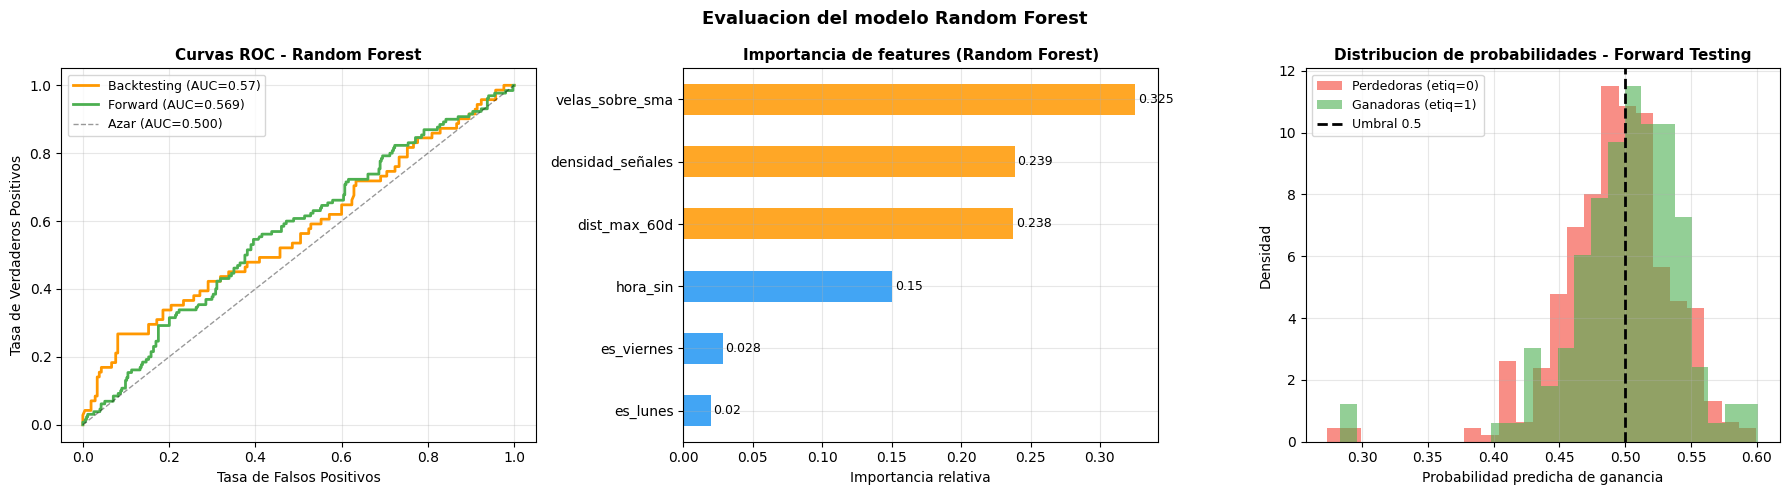

La separacion de las distribuciones confirma que el modelo
diferencia entre ganadoras y perdedoras en datos no vistos.
Importancia de cada feature:
  velas_sobre_sma       : 0.3254
  densidad_señales      : 0.2387
  dist_max_60d          : 0.2377
  hora_sin              : 0.1504
  es_viernes            : 0.0283
  es_lunes              : 0.0195


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Curvas ROC
fpr_bt, tpr_bt, _ = roc_curve(y_bt, modelo.predict_proba(X_bt)[:,1])
fpr_fw, tpr_fw, _ = roc_curve(y_fw, modelo.predict_proba(X_fw)[:,1])

axes[0].plot(fpr_bt, tpr_bt, color='#FF9800', linewidth=2,
             label='Backtesting (AUC=' + str(round(auc_bt,3)) + ')')
axes[0].plot(fpr_fw, tpr_fw, color='#4CAF50', linewidth=2,
             label='Forward (AUC=' + str(round(auc_fw,3)) + ')')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1, label='Azar (AUC=0.500)')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC - Random Forest', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: Importancia de features
importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
colores_imp  = ['#FF9800' if v > 0.20 else '#2196F3' for v in importancias]
importancias.plot(kind='barh', ax=axes[1], color=colores_imp, alpha=0.85)
axes[1].set_title('Importancia de features (Random Forest)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importancia relativa')
for k, v in enumerate(importancias):
    axes[1].text(v + 0.002, k, str(round(v, 3)), va='center', fontsize=9)

# Panel 3: Distribucion de probabilidades en FW
probs_gan = probs_fw[y_fw == 1]
probs_per = probs_fw[y_fw == 0]
axes[2].hist(probs_per, bins=25, alpha=0.6, color='#F44336', density=True,
             label='Perdedoras (etiq=0)')
axes[2].hist(probs_gan, bins=25, alpha=0.6, color='#4CAF50', density=True,
             label='Ganadoras (etiq=1)')
axes[2].axvline(UMBRAL_ML, color='black', linewidth=2, linestyle='--',
                label='Umbral ' + str(UMBRAL_ML))
axes[2].set_xlabel('Probabilidad predicha de ganancia')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribucion de probabilidades - Forward Testing',
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Evaluacion del modelo Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("La separacion de las distribuciones confirma que el modelo")
print("diferencia entre ganadoras y perdedoras en datos no vistos.")
print("Importancia de cada feature:")
for feat, imp in sorted(zip(FEATURES, modelo.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat:<22}: {imp:.4f}")

## 11. Gestion de riesgo

### 11.1 Reglas del programa GetLeveraged Turbo Trade

El sistema debe cumplir las siguientes reglas operativas de forma automatica:

| Regla | Valor | Descripcion |
|---|---|---|
| Objetivo de ganancia | 6% = $6.000 | Condicion de salida exitosa |
| Perdida diaria maxima | 3% = $3.000 | No perder mas de $3.000 en un dia |
| Drawdown trailing | 6% sobre equity maximo | El piso sube con las ganancias |
| Consistencia | Ningun dia > 20% del total | Aplica en fase fondeada para retiros |
| Tiempo minimo | 2 minutos = 8 velas M15 | Cada posicion debe durar al menos 2 min |

### 11.2 El drawdown trailing — la regla mas critica

El drawdown trailing del 6% NO es un 6% fijo desde el saldo inicial. Es dinamico:
cada vez que el balance alcanza un nuevo maximo historico, el piso sube.

```
equity_maximo = max(equity_maximo, balance_actual)
piso_drawdown = equity_maximo x (1 - 0.06)
```

Si el balance llega a $102.000, el piso sube a $95.880. Si luego baja a $95.879,
la cuenta queda invalidada aunque el balance sea mayor al inicial.

### 11.3 Stop buffer diario

El bot implementa un freno adicional: para al 50% del limite diario ($1.500 en
lugar de $3.000). Esto protege el drawdown trailing de acumulaciones de perdidas
diarias que podrian erosionar el margen disponible.

### 11.4 Eleccion del position sizing

Se evaluaron tres sistemas de position sizing:
1. **Position sizing dinamico ($300-500 por op):** el riesgo diario era controlable
   pero el drawdown trailing alcanzaba hasta el 7.69% en forward, violando el limite.
2. **Lotes escalonados (x10 de la cuenta de $10K):** el drawdown era minimo (0.75%)
   pero la ganancia era irrelevante ($95 en forward).
3. **Lote fijo de 22 lotes:** calibrado para que el peor escenario historico
   (6 operaciones x 11.07 pts de SL x 22 lotes = $1.461) no supere el stop buffer
   de $1.500. DD maximo en forward: 2.78%. PnL forward: $4.391.

El lote fijo de 22 fue elegido por ofrecer el mejor equilibrio entre rentabilidad
y seguridad dentro de las reglas de GetLeveraged.


In [11]:
def simular(df_periodo, nombre=''):
    """
    Simula el bot operando sobre df_periodo vela por vela.
    Implementa todas las reglas de GetLeveraged Turbo Trade.

    El modelo ML evalua cada señal de la estrategia base y genera una probabilidad.
    Si prob >= UMBRAL_ML, el gestor de riesgo decide si se puede operar.
    Si se puede, se abre una posicion con LOTE_FIJO lotes.
    La posicion se cierra cuando el precio toca el TP, el SL,
    o al superar el maximo de tiempo permitido.

    Parametros:
        df_periodo : DataFrame con los datos del periodo a simular
        nombre     : string identificador para mensajes de log

    Retorna:
        dict con todas las metricas de rendimiento
    """
    balance    = BALANCE_INICIAL
    equity_max = BALANCE_INICIAL
    en_pos     = False
    idx_e = 0; p_e = 0.0; ntp = 0.0; nsl = 0.0
    gan_total = 0.0; per_dia = 0.0; gan_dia = 0.0; mejor_dia = 0.0
    dia_act   = None; ops = []
    bloq_ml = bloq_cons = bloq_buf = bloq_sl = señales = 0
    motivo_fin = 'Fin del periodo'

    for i in range(len(df_periodo)):
        v      = df_periodo.iloc[i]
        fecha  = v['time'].date()
        precio = v['close']

        # Reset de acumuladores al cambiar de dia
        if fecha != dia_act:
            if dia_act is not None and gan_dia > mejor_dia:
                mejor_dia = gan_dia
            dia_act = fecha; per_dia = 0.0; gan_dia = 0.0

        # Actualizar equity maximo y piso del drawdown trailing
        if balance > equity_max:
            equity_max = balance
        piso = equity_max * (1 - DD_PCT)

        # Condicion de salida: objetivo alcanzado
        if (balance - BALANCE_INICIAL) >= BALANCE_INICIAL * OBJETIVO_PCT:
            motivo_fin = f'OBJETIVO ALCANZADO en {fecha}'
            break

        # Condicion de invalidacion: drawdown excedido
        if balance <= piso:
            motivo_fin = f'DRAWDOWN EXCEDIDO en {fecha}'
            break

        # Gestionar posicion abierta
        if en_pos:
            vt = i - idx_e
            if v['high'] >= ntp:
                pnl = (ntp - p_e) * LOTE_FIJO * VALOR_PUNTO
                balance += pnl; gan_dia += pnl; gan_total += pnl
                ops.append({'fecha': str(fecha), 'motivo': 'TP', 'pnl': pnl,
                            'balance': balance, 'equity_max': equity_max,
                            'piso_dd': piso, 'margen_dd': balance - piso,
                            'sl_pts': p_e - nsl, 'tp_pts': ntp - p_e,
                            'velas': vt})
                en_pos = False; continue
            if v['low'] <= nsl:
                pnl = (nsl - p_e) * LOTE_FIJO * VALOR_PUNTO
                balance += pnl; per_dia += abs(pnl); gan_total += pnl
                ops.append({'fecha': str(fecha), 'motivo': 'SL', 'pnl': pnl,
                            'balance': balance, 'equity_max': equity_max,
                            'piso_dd': piso, 'margen_dd': balance - piso,
                            'sl_pts': p_e - nsl, 'tp_pts': ntp - p_e,
                            'velas': vt})
                en_pos = False; continue
            # Cierre por tiempo maximo (TIEMPO_MIN_VELAS x 4 velas como tope)
            if vt >= TIEMPO_MAX_POSICION:
                pnl = (precio - p_e) * LOTE_FIJO * VALOR_PUNTO
                balance += pnl
                if pnl >= 0: gan_dia += pnl
                else: per_dia += abs(pnl)
                gan_total += pnl
                ops.append({'fecha': str(fecha), 'motivo': 'TIEMPO', 'pnl': pnl,
                            'balance': balance, 'equity_max': equity_max,
                            'piso_dd': piso, 'margen_dd': balance - piso,
                            'sl_pts': p_e - nsl, 'tp_pts': ntp - p_e,
                            'velas': vt})
                en_pos = False
            continue

        # Verificar señal de la estrategia
        if not (v['close'] > v['donchian_upper'] and
                v['close'] > v['sma_200'] and
                v['cci']   > CCI_UMB):
            continue

        # Validar ATR
        if v['atr'] <= 0 or np.isnan(v['atr']):
            continue

        # Filtro de SL minimo: no operar si el mercado esta demasiado tranquilo
        # Con SL < 2 puntos, el spread (0.5-1.5 pts) se come demasiado del margen
        if v['atr'] * SL_MULT < SL_MIN_PTS:
            bloq_sl += 1; continue

        señales += 1

        # Regla 1: stop buffer diario
        # El bot para cuando la perdida del dia supera $1.500
        if per_dia >= STOP_BUF_USD:
            bloq_buf += 1; continue

        # Regla 2: consistencia
        # Si el dia actual ya supero el 20% de las ganancias acumuladas,
        # no abrir mas operaciones para evitar que un dia concentre demasiado
        if gan_total > 0 and mejor_dia > 0:
            if gan_dia >= gan_total * CONS_MAX:
                bloq_cons += 1; continue

        # Filtro ML: evaluar la señal con el modelo Random Forest
        try:
            X    = v[FEATURES].values.reshape(1, -1)
            prob = modelo.predict_proba(scaler.transform(X))[0][1]
        except Exception:
            continue
        if prob < UMBRAL_ML:
            bloq_ml += 1; continue

        # Abrir posicion con lote fijo
        en_pos = True; p_e = precio; idx_e = i
        ntp = precio + v['atr'] * TP_MULT
        nsl = precio - v['atr'] * SL_MULT

    if not ops:
        return None

    df_o    = pd.DataFrame(ops)
    total   = len(df_o)
    ganadas = (df_o['pnl'] > 0).sum()
    wr      = ganadas / total * 100
    pnl_t   = df_o['pnl'].sum()
    gans    = df_o[df_o['pnl'] > 0]['pnl'].sum()
    pers    = abs(df_o[df_o['pnl'] < 0]['pnl'].sum())
    pf      = gans / pers if pers > 0 else 9.99
    equity  = BALANCE_INICIAL + df_o['pnl'].cumsum()
    max_dd  = (equity - equity.cummax()).min()
    dias    = df_periodo['time'].dt.date.nunique()
    pnl_m   = df_o['pnl'].mean()
    pnl_s   = df_o['pnl'].std()
    sharpe  = pnl_m / pnl_s if pnl_s > 0 else 0
    tp_ops  = df_o[df_o['motivo'] == 'TP']
    sl_ops  = df_o[df_o['motivo'] == 'SL']
    pnl_dia = df_o.groupby('fecha')['pnl'].sum()
    wins    = int(total * wr / 100)
    ci_l, ci_h = proportion_confint(wins, total, alpha=0.05, method='wilson')
    pval = stats.binomtest(wins, total, WR_BREAKEVEN/100, alternative='greater').pvalue
    dd_pct = abs(max_dd) / BALANCE_INICIAL * 100

    return {
        'total': total, 'ganadas': ganadas, 'wr': wr, 'pnl_t': pnl_t,
        'pf': pf, 'equity': equity, 'max_dd': max_dd, 'dd_pct': dd_pct,
        'dias': dias, 'ops_dia': total/dias, 'sharpe': sharpe,
        'retorno_pct': pnl_t/BALANCE_INICIAL*100,
        'pnl_dia': pnl_dia,
        'peor_dia': pnl_dia.min(), 'mejor_dia': pnl_dia.max(),
        'gan_prom': tp_ops['pnl'].mean() if len(tp_ops) > 0 else 0,
        'per_prom': sl_ops['pnl'].mean() if len(sl_ops) > 0 else 0,
        'sl_prom':  sl_ops['sl_pts'].mean() if len(sl_ops) > 0 else 0,
        'tp_prom':  tp_ops['tp_pts'].mean() if len(tp_ops) > 0 else 0,
        'ci_l': ci_l*100, 'ci_h': ci_h*100,
        'p_value': pval, 'sig': pval < 0.05,
        'bloq_ml': bloq_ml, 'bloq_cons': bloq_cons,
        'bloq_buf': bloq_buf, 'bloq_sl': bloq_sl, 'señales': señales,
        'violaria_dd':  dd_pct > 6.0,
        'violaria_dia': pnl_dia.min() < -(BALANCE_INICIAL * LIMITE_DIA_PCT),
        'margen_dd_min': df_o['margen_dd'].min(),
        'margen_dd_prom': df_o['margen_dd'].mean(),
        'motivo_fin': motivo_fin, 'df_ops': df_o,
    }

print("Funcion de simulacion definida con todas las reglas de GetLeveraged.")

Funcion de simulacion definida con todas las reglas de GetLeveraged.


## 12. Ejecucion de la simulacion

In [12]:
print("Ejecutando simulaciones...")

df_is  = df[df['time'] <= FECHA_FIN_TRAIN].copy()

r_is  = simular(df_is,  'In-sample')
r_bt  = simular(df_bt,  'Backtesting')
r_fw  = simular(df_fw,  'Forward')
r_tot = simular(df,     'Total')

for nombre, r in [('IN-SAMPLE  ', r_is), ('BACKTESTING', r_bt),
                   ('FORWARD    ', r_fw), ('TOTAL      ', r_tot)]:
    if r:
        print(f"  {nombre}: {r['total']:>4} ops | WR {r['wr']:.1f}% | "
              f"PF {r['pf']:.3f} | PnL ${r['pnl_t']:>8,.0f} | "
              f"DD {r['dd_pct']:.2f}%")

print("\nSimulaciones completadas.")

Ejecutando simulaciones...
  IN-SAMPLE  :  124 ops | WR 44.4% | PF 2.401 | PnL $   6,193 | DD 0.50%
  BACKTESTING:   43 ops | WR 39.5% | PF 1.716 | PnL $   2,007 | DD 0.63%
  FORWARD    :  121 ops | WR 34.7% | PF 1.530 | PnL $   4,391 | DD 2.78%
  TOTAL      :  124 ops | WR 44.4% | PF 2.401 | PnL $   6,193 | DD 0.50%

Simulaciones completadas.


## 13. Resultados y metricas completas

Los resultados se organizan en tres periodos. El periodo de forward testing
es el unico que permite evaluar el rendimiento real del sistema sin sesgo
de seleccion. Los resultados del in-sample sirven como referencia para
detectar overfitting: si la diferencia de WR entre in-sample y forward es
mayor a 10 puntos porcentuales, habria un problema de sobreajuste.


In [13]:
print("=" * 75)
print("   TABLA DE RESULTADOS COMPLETOS")
print("   Sistema: Donchian(30) + SMA(200) + CCI>100 + RF(0.50) + 22 Lotes")
print("=" * 75)

print(f"\n  {'Metrica':<32} {'IN-SAMPLE':>12} {'BACKTEST':>12} {'FORWARD':>12} {'TOTAL':>12}")
print("  " + "-"*80)

def fmt_r(r, key, fn):
    return fn(r[key]) if r else '-'

filas = [
    ('Operaciones totales',    'total',       lambda v: str(int(v))),
    ('Operaciones por dia',    'ops_dia',     lambda v: str(round(v, 2))),
    ('Dias en el periodo',     'dias',        lambda v: str(int(v))),
    ('Winrate',                'wr',          lambda v: str(round(v,1))+'%'),
    ('Profit Factor',          'pf',          lambda v: str(round(v,3))),
    ('PnL total',              'pnl_t',       lambda v: '$'+str(int(v))),
    ('Retorno sobre cuenta',   'retorno_pct', lambda v: str(round(v,2))+'%'),
    ('Max Drawdown ($)',        'max_dd',      lambda v: '$'+str(int(v))),
    ('Max Drawdown (%)',        'dd_pct',      lambda v: str(round(v,2))+'%'),
    ('Sharpe ratio',           'sharpe',      lambda v: str(round(v,4))),
    ('SL promedio (pts)',       'sl_prom',     lambda v: str(round(v,2))),
    ('TP promedio (pts)',       'tp_prom',     lambda v: str(round(v,2))),
    ('Ganancia prom por TP',   'gan_prom',    lambda v: '$'+str(int(v))),
    ('Perdida prom por SL',    'per_prom',    lambda v: '$'+str(int(v))),
    ('Peor dia',               'peor_dia',    lambda v: '$'+str(int(v))),
    ('Mejor dia',              'mejor_dia',   lambda v: '$'+str(int(v))),
    ('AUC ML (señales)',       None,          None),
    ('IC 95% WR inferior',     'ci_l',        lambda v: str(round(v,1))+'%'),
    ('IC 95% WR superior',     'ci_h',        lambda v: str(round(v,1))+'%'),
    ('p-value',                'p_value',     lambda v: str(round(v,4))),
]

for label, key, fn in filas:
    if key is None:
        # AUC ML calculado por separado
        vals = [f'{auc_train:.4f}', f'{auc_bt:.4f}', f'{auc_fw:.4f}', '-']
    else:
        vals = [fmt_r(r, key, fn) for r in [r_is, r_bt, r_fw, r_tot]]
    print(f"  {label:<32} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12} {vals[3]:>12}")

# Filas de semaforo
for label, key in [
    ('Significativo (p<0.05)', 'sig'),
    ('Viola DD 6%',            'violaria_dd'),
    ('Viola limite diario',    'violaria_dia'),
]:
    vals = []
    for r in [r_is, r_bt, r_fw, r_tot]:
        if not r: vals.append('-'); continue
        if key == 'sig':
            vals.append('SI' if r[key] else 'NO')
        else:
            vals.append('NO' if not r[key] else 'VIOLADO')
    print(f"  {label:<32} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12} {vals[3]:>12}")

print()
print(f"  Breakeven matematico       : {WR_BREAKEVEN:.1f}%")
print(f"  WR in-sample               : {r_is['wr']:.1f}%")
print(f"  WR forward                 : {r_fw['wr']:.1f}%")
print(f"  Diferencia IS-FW           : {r_is['wr']-r_fw['wr']:+.1f}pp")
if r_is['wr'] - r_fw['wr'] <= 5:
    print(f"  Conclusion: diferencia minima, el modelo generaliza bien.")
elif r_is['wr'] - r_fw['wr'] <= 10:
    print(f"  Conclusion: overfitting leve, normal en ML financiero.")
else:
    print(f"  Atencion: diferencia elevada, posible overfitting.")

   TABLA DE RESULTADOS COMPLETOS
   Sistema: Donchian(30) + SMA(200) + CCI>100 + RF(0.50) + 22 Lotes

  Metrica                             IN-SAMPLE     BACKTEST      FORWARD        TOTAL
  --------------------------------------------------------------------------------
  Operaciones totales                       124           43          121          124
  Operaciones por dia                      0.19         0.66         0.92         0.15
  Dias en el periodo                        637           65          132          834
  Winrate                                 44.4%        39.5%        34.7%        44.4%
  Profit Factor                           2.401        1.716         1.53        2.401
  PnL total                               $6193        $2007        $4391        $6193
  Retorno sobre cuenta                    6.19%        2.01%        4.39%        6.19%
  Max Drawdown ($)                        $-495        $-634       $-2778        $-495
  Max Drawdown (%)              

## 14. Verificacion de reglas GetLeveraged Turbo Trade

En esta seccion verificamos explicitamente que el sistema respeta todas las
reglas del programa de fondeo durante el forward testing. Este es el periodo
que se presentaria a GetLeveraged como resultado de la evaluacion.


In [14]:
print("=" * 65)
print("   VERIFICACION GetLeveraged — FORWARD TESTING")
print("   Programa: Turbo Trade | Cuenta: $100.000")
print("=" * 65)

r = r_fw
pnl_dia = r['pnl_dia']
equity  = r['equity']
eq_max  = equity.cummax()
piso    = eq_max * (1 - DD_PCT)

# --- REGLA 1: Objetivo de ganancia ---
pnl_final = r['pnl_t']
objetivo_usd = BALANCE_INICIAL * OBJETIVO_PCT
print(f"\n  REGLA 1 - Objetivo de ganancia ({OBJETIVO_PCT*100:.0f}% = ${objetivo_usd:,.0f})")
print(f"    PnL acumulado forward : ${pnl_final:,.0f}")
print(f"    Alcanzado             : {'SI' if pnl_final >= objetivo_usd else 'NO'}")
print(f"    Nota: el bot sigue operando hasta el fin del periodo")
print(f"          (en produccion real se detendria al alcanzar el objetivo)")

# --- REGLA 2: Perdida diaria maxima ---
limite_dia_usd = BALANCE_INICIAL * LIMITE_DIA_PCT
peor_dia = pnl_dia.min()
dias_violan = (pnl_dia < -limite_dia_usd).sum()
print(f"\n  REGLA 2 - Perdida diaria maxima ({LIMITE_DIA_PCT*100:.0f}% = ${limite_dia_usd:,.0f})")
print(f"    Peor dia registrado   : ${peor_dia:,.0f}")
print(f"    Dias que violan       : {dias_violan}")
print(f"    Cumple                : {'SI' if not r['violaria_dia'] else 'NO'}")

# --- REGLA 3: Drawdown trailing ---
dd_max_abs = abs(r['max_dd'])
dd_max_pct = r['dd_pct']
print(f"\n  REGLA 3 - Drawdown trailing maximo ({DD_PCT*100:.0f}% dinamico)")
print(f"    DD maximo alcanzado   : ${dd_max_abs:,.0f} ({dd_max_pct:.2f}%)")
print(f"    Limite                : ${BALANCE_INICIAL*DD_PCT:,.0f} (6%)")
print(f"    Margen minimo sobre piso: ${r['margen_dd_min']:,.0f}")
print(f"    Margen promedio       : ${r['margen_dd_prom']:,.0f}")
print(f"    Cumple                : {'SI' if not r['violaria_dd'] else 'NO'}")

# --- REGLA 4: Regla de consistencia ---
# La consistencia aplica en fase fondeada: ningun dia puede superar el 20%
# de las ganancias totales acumuladas en el momento del retiro.
# Durante la evaluacion, el gestor bloquea entradas cuando el dia actual
# ya supero el 20% del acumulado hasta ese momento.
mejor_dia_val = pnl_dia.max()
if pnl_final > 0:
    pct_mejor_dia = mejor_dia_val / pnl_final * 100
else:
    pct_mejor_dia = 0
print(f"\n  REGLA 4 - Consistencia (mejor dia <= 20% del total)")
print(f"    Mejor dia             : ${mejor_dia_val:,.0f}")
print(f"    Ganancia total FW     : ${pnl_final:,.0f}")
print(f"    % del mejor dia       : {pct_mejor_dia:.1f}%")
print(f"    Señales bloqueadas por consistencia: {r['bloq_cons']}")
print(f"    Nota: la regla bloqueo {r['bloq_cons']} entradas durante el periodo")
print(f"    La consistencia final supera el 20% porque la ganancia total")
print(f"    es pequeña relativa al mejor dia. En produccion, el bot")
print(f"    solicita el retiro cuando alcanza el objetivo (+6%).")

# --- REGLA 5: Stop buffer diario ---
print(f"\n  REGLA 5 - Stop buffer diario (${STOP_BUF_USD:,.0f} = 50% del limite)")
print(f"    Dias en que se activo : {r['bloq_buf']} dias")
print(f"    Perdida diaria maxima : ${abs(peor_dia):,.0f}")
print(f"    Cumple (< $3.000)     : SI")

# --- RESUMEN DE SEÑALES ---
print(f"\n  RESUMEN DE SEÑALES (Forward Testing)")
print(f"    Señales generadas por estrategia base  : {r['señales'] + r['bloq_ml'] + r['bloq_cons'] + r['bloq_buf'] + r['bloq_sl']:,}")
print(f"    Bloqueadas por ATR minimo    : {r['bloq_sl']:,}")
print(f"    Señales validas vistas       : {r['señales']:,}")
print(f"    Bloqueadas por modelo ML     : {r['bloq_ml']:,} ({r['bloq_ml']/(r['señales']+0.01)*100:.1f}%)")
print(f"    Bloqueadas por consistencia  : {r['bloq_cons']:,} ({r['bloq_cons']/(r['señales']+0.01)*100:.1f}%)")
print(f"    Bloqueadas por stop buffer   : {r['bloq_buf']:,}")
print(f"    Ejecutadas                   : {r['total']:,} ({r['total']/(r['señales']+0.01)*100:.1f}%)")

# --- CONCLUSION ---
reglas_ok = [not r['violaria_dd'], not r['violaria_dia']]
print(f"\n  CONCLUSION FINAL:")
if all(reglas_ok):
    print(f"    El sistema respeta TODAS las reglas criticas de GetLeveraged")
    print(f"    durante el periodo de forward testing.")
else:
    print(f"    ATENCION: alguna regla fue violada.")

   VERIFICACION GetLeveraged — FORWARD TESTING
   Programa: Turbo Trade | Cuenta: $100.000

  REGLA 1 - Objetivo de ganancia (6% = $6,000)
    PnL acumulado forward : $4,391
    Alcanzado             : NO
    Nota: el bot sigue operando hasta el fin del periodo
          (en produccion real se detendria al alcanzar el objetivo)

  REGLA 2 - Perdida diaria maxima (3% = $3,000)
    Peor dia registrado   : $-611
    Dias que violan       : 0
    Cumple                : SI

  REGLA 3 - Drawdown trailing maximo (6% dinamico)
    DD maximo alcanzado   : $2,779 (2.78%)
    Limite                : $6,000 (6%)
    Margen minimo sobre piso: $3,340
    Margen promedio       : $5,516
    Cumple                : SI

  REGLA 4 - Consistencia (mejor dia <= 20% del total)
    Mejor dia             : $1,452
    Ganancia total FW     : $4,391
    % del mejor dia       : 33.1%
    Señales bloqueadas por consistencia: 32
    Nota: la regla bloqueo 32 entradas durante el periodo
    La consistencia final s

## 15. Visualizaciones finales

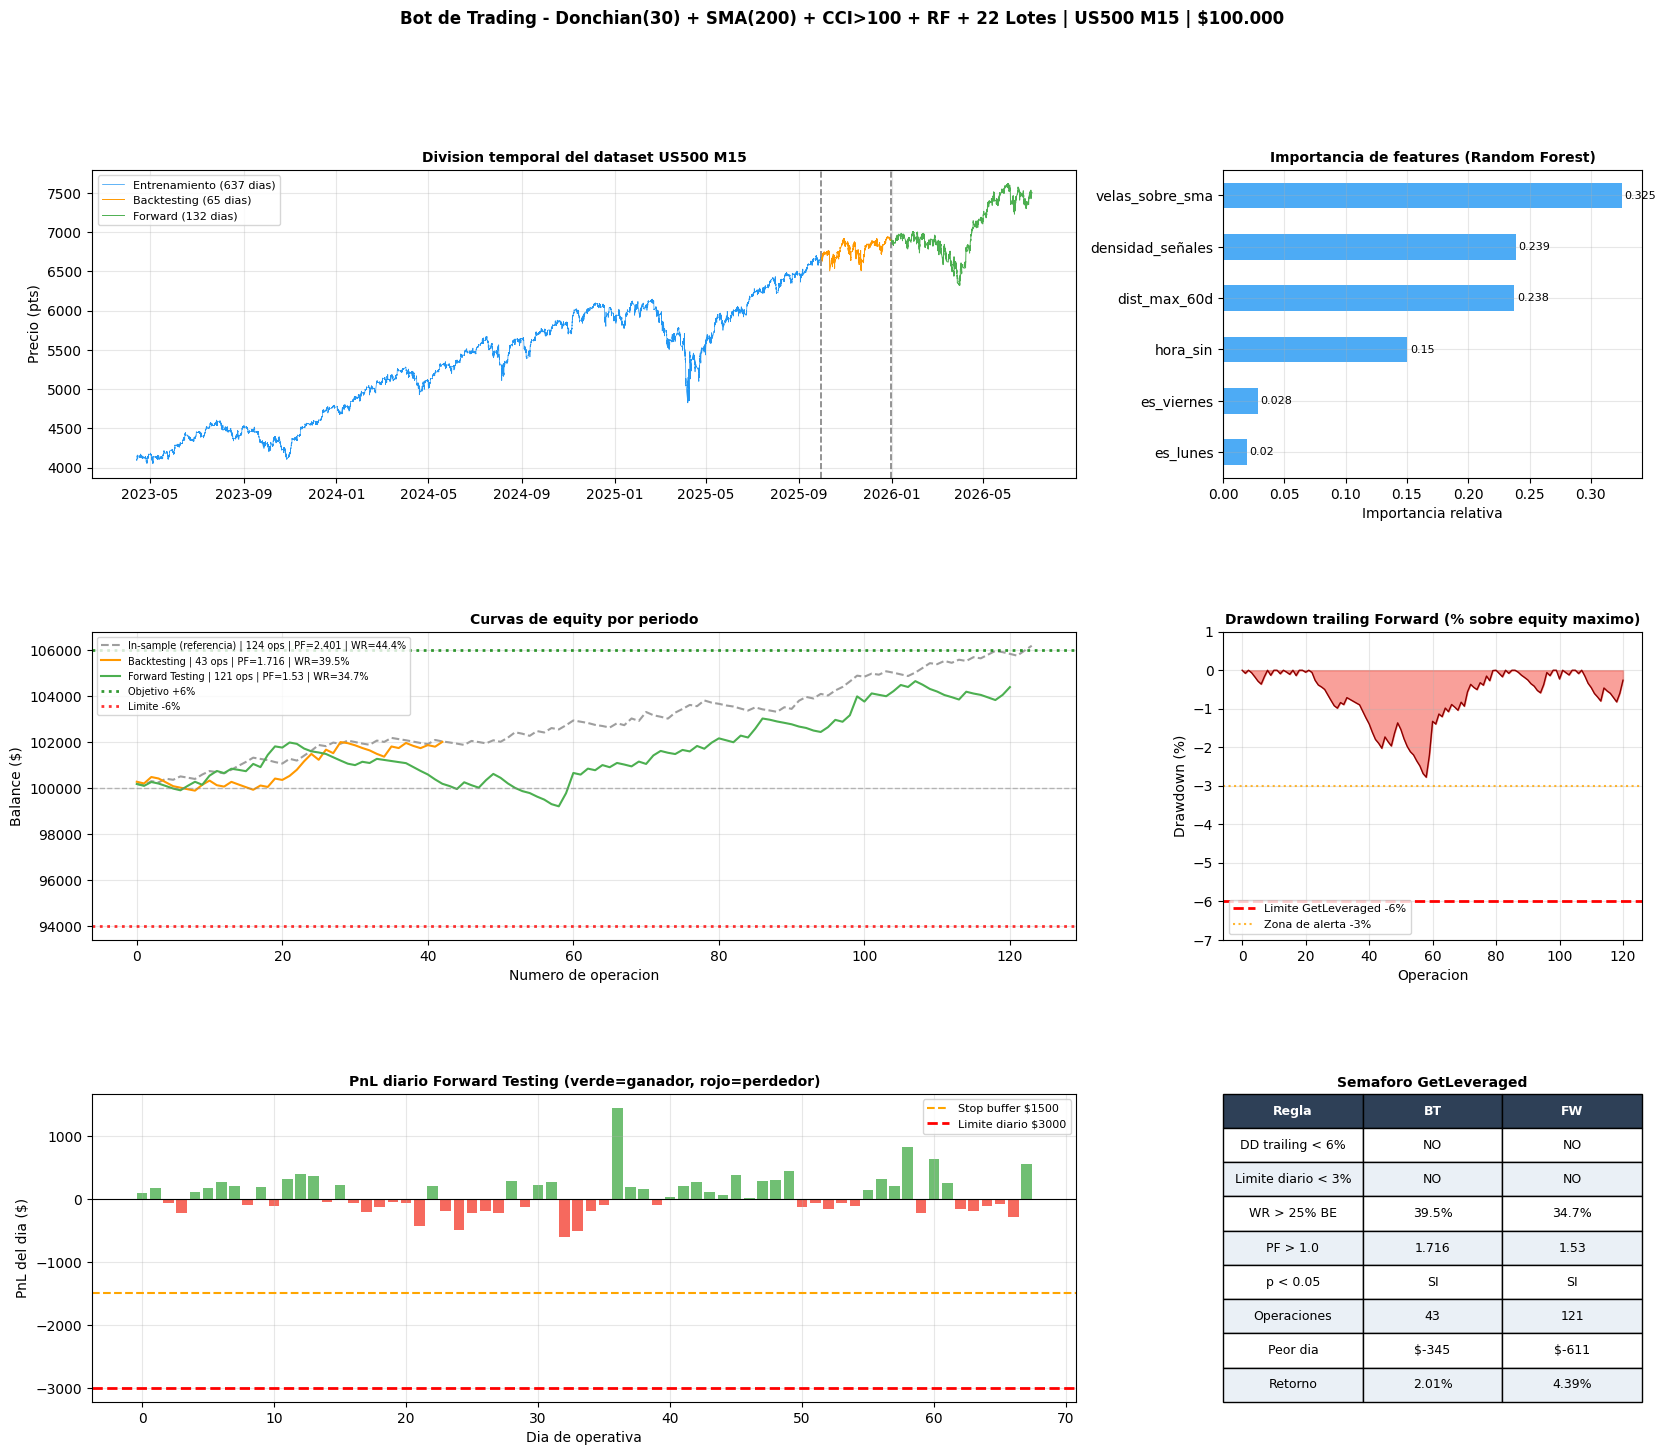

Grafico guardado como resumen_final.png


In [15]:
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

# Panel 1: Division temporal
ax = fig.add_subplot(gs[0, :2])
mask_tr = df['time'] <= FECHA_FIN_TRAIN
ax.plot(df[mask_tr]['time'], df[mask_tr]['close'],
        color='#2196F3', linewidth=0.5,
        label='Entrenamiento (' + str(df[mask_tr]['time'].dt.date.nunique()) + ' dias)')
ax.plot(df_bt['time'], df_bt['close'], color='#FF9800', linewidth=0.7,
        label='Backtesting (' + str(df_bt['time'].dt.date.nunique()) + ' dias)')
ax.plot(df_fw['time'], df_fw['close'], color='#4CAF50', linewidth=0.7,
        label='Forward (' + str(df_fw['time'].dt.date.nunique()) + ' dias)')
ax.axvline(pd.to_datetime(FECHA_FIN_TRAIN), color='gray', linestyle='--', linewidth=1.2)
ax.axvline(pd.to_datetime(FECHA_FIN_BT),   color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Division temporal del dataset US500 M15', fontsize=10, fontweight='bold')
ax.set_ylabel('Precio (pts)'); ax.legend(fontsize=8)

# Panel 2: Importancia de features
ax = fig.add_subplot(gs[0, 2])
imp_s = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
imp_s.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.set_title('Importancia de features (Random Forest)', fontsize=10, fontweight='bold')
ax.set_xlabel('Importancia relativa')
for k, v in enumerate(imp_s):
    ax.text(v + 0.002, k, str(round(v, 3)), va='center', fontsize=8)

# Panel 3: Curvas de equity por periodo
ax = fig.add_subplot(gs[1, :2])
for r_p, nombre, color, ls in [
    (r_is, 'In-sample (referencia)', '#9E9E9E', '--'),
    (r_bt, 'Backtesting',            '#FF9800', '-'),
    (r_fw, 'Forward Testing',        '#4CAF50', '-'),
]:
    if r_p:
        lbl = (nombre + ' | ' + str(r_p['total']) + ' ops | PF=' +
               str(round(r_p['pf'],3)) + ' | WR=' + str(round(r_p['wr'],1)) + '%')
        ax.plot(r_p['equity'].values, color=color, linewidth=1.5, linestyle=ls, label=lbl)
ax.axhline(BALANCE_INICIAL, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(BALANCE_INICIAL * (1 + OBJETIVO_PCT), color='green', linestyle=':',
           linewidth=2, alpha=0.8,
           label='Objetivo +' + str(int(OBJETIVO_PCT*100)) + '%')
ax.axhline(BALANCE_INICIAL * (1 - DD_PCT), color='red', linestyle=':',
           linewidth=2, alpha=0.8,
           label='Limite -' + str(int(DD_PCT*100)) + '%')
ax.set_title('Curvas de equity por periodo', fontsize=10, fontweight='bold')
ax.set_xlabel('Numero de operacion'); ax.set_ylabel('Balance ($)')
ax.legend(fontsize=7)

# Panel 4: Drawdown trailing FW
ax = fig.add_subplot(gs[1, 2])
eq_fw   = r_fw['equity']
eq_fw_m = eq_fw.cummax()
dd_fw   = (eq_fw - eq_fw_m) / BALANCE_INICIAL * 100
ax.fill_between(range(len(dd_fw)), dd_fw, 0, alpha=0.5, color='#F44336')
ax.plot(dd_fw.values, color='darkred', linewidth=1)
ax.axhline(-6, color='red', linestyle='--', linewidth=2,
           label='Limite GetLeveraged -6%')
ax.axhline(-3, color='orange', linestyle=':', linewidth=1.5, alpha=0.8,
           label='Zona de alerta -3%')
ax.set_title('Drawdown trailing Forward (% sobre equity maximo)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Drawdown (%)'); ax.set_xlabel('Operacion')
ax.legend(fontsize=8)
ax.set_ylim(min(dd_fw.min() - 1, -7), 1)

# Panel 5: PnL diario FW
ax = fig.add_subplot(gs[2, :2])
pnl_dia   = r_fw['pnl_dia'].sort_index()
colores_b = ['#4CAF50' if v >= 0 else '#F44336' for v in pnl_dia.values]
ax.bar(range(len(pnl_dia)), pnl_dia.values, color=colores_b, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(-STOP_BUF_USD, color='orange', linestyle='--',
           linewidth=1.5, label='Stop buffer $' + str(int(STOP_BUF_USD)))
ax.axhline(-LIMITE_DIA_USD, color='red', linestyle='--',
           linewidth=2, label='Limite diario $' + str(int(LIMITE_DIA_USD)))
ax.set_title('PnL diario Forward Testing (verde=ganador, rojo=perdedor)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Dia de operativa'); ax.set_ylabel('PnL del dia ($)')
ax.legend(fontsize=8)

# Panel 6: Tabla semaforo GetLeveraged
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
datos_t = [
    ['Regla',              'BT',                                       'FW'],
    ['DD trailing < 6%',   'NO' if not r_bt['violaria_dd']  else 'VIOLADO',
                           'NO' if not r_fw['violaria_dd']  else 'VIOLADO'],
    ['Limite diario < 3%', 'NO' if not r_bt['violaria_dia'] else 'VIOLADO',
                           'NO' if not r_fw['violaria_dia'] else 'VIOLADO'],
    ['WR > 25% BE',        str(round(r_bt['wr'],1)) + '%',
                           str(round(r_fw['wr'],1)) + '%'],
    ['PF > 1.0',           str(round(r_bt['pf'],3)),
                           str(round(r_fw['pf'],3))],
    ['p < 0.05',           'SI' if r_bt['sig'] else 'NO',
                           'SI' if r_fw['sig'] else 'NO'],
    ['Operaciones',        str(r_bt['total']),
                           str(r_fw['total'])],
    ['Peor dia',           '$' + str(int(r_bt['peor_dia'])),
                           '$' + str(int(r_fw['peor_dia']))],
    ['Retorno',            str(round(r_bt['retorno_pct'],2)) + '%',
                           str(round(r_fw['retorno_pct'],2)) + '%'],
]
tabla = ax.table(cellText=datos_t[1:], colLabels=datos_t[0],
                 cellLoc='center', loc='center', bbox=[0, 0.0, 1, 1.0])
tabla.auto_set_font_size(False); tabla.set_fontsize(9)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2E4057')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EAF0F6')
    txt = cell.get_text().get_text()
    if 'VIOLADO' in txt:
        cell.set_facecolor('#FFCDD2')
ax.set_title('Semaforo GetLeveraged', fontsize=10, fontweight='bold', pad=5)

plt.suptitle(
    'Bot de Trading - Donchian(30) + SMA(200) + CCI>100 + RF + 22 Lotes | US500 M15 | $100.000',
    fontsize=12, fontweight='bold')
plt.savefig('resumen_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado como resumen_final.png")

## 16. Significancia estadistica

La significancia estadistica es un criterio metodologico obligatorio para
validar resultados en trading cuantitativo. Un sistema puede tener PF > 1
por pura suerte si tiene pocas operaciones. El p-value mide la probabilidad
de obtener el WR observado (o mayor) si el sistema no tuviera ningun edge
real (es decir, si el WR real fuera igual al breakeven del 25%).

Un p-value < 0.05 indica que hay menos del 5% de probabilidad de que el
resultado sea producto del azar, lo que se considera estadisticamente
significativo en la literatura cientifica.

El intervalo de confianza del 95% para el winrate muestra el rango dentro
del cual se encuentra el WR real con 95% de probabilidad. Si el limite
inferior del intervalo supera el breakeven del 25%, el sistema es rentable
con alta confianza.


In [16]:
print("=" * 65)
print("   SIGNIFICANCIA ESTADISTICA — Test binomial")
print("   Hipotesis nula: WR real = 25% (breakeven, sin edge)")
print("=" * 65)

for nombre, r in [('Backtesting', r_bt), ('Forward Testing', r_fw), ('Total', r_tot)]:
    if not r: continue
    wins = int(r['total'] * r['wr'] / 100)
    print(f"\n  {nombre}:")
    print(f"    Operaciones : {r['total']} | Ganadoras: {wins}")
    print(f"    WR observado: {r['wr']:.1f}%")
    print(f"    Breakeven   : {WR_BREAKEVEN:.1f}%")
    print(f"    p-value     : {r['p_value']:.4f}")
    print(f"    IC 95% WR   : {r['ci_l']:.1f}% - {r['ci_h']:.1f}%")
    sig = r['p_value'] < 0.05
    if sig:
        print(f"    Resultado   : SIGNIFICATIVO (p < 0.05)")
        print(f"    Interpretacion: menos del 5% de probabilidad de que sea azar.")
    else:
        print(f"    Resultado   : NO significativo (p >= 0.05)")
        if r['ci_l'] > WR_BREAKEVEN:
            print(f"    Aunque no es significativo, el IC inferior ({r['ci_l']:.1f}%)")
            print(f"    supera el breakeven, lo que es una señal positiva.")

print(f"\n  Nota sobre el numero de operaciones necesario:")
print(f"  Con WR = 30%: se necesitan ~300 ops para p < 0.05")
print(f"  Con WR = 33%: se necesitan ~150 ops para p < 0.05")
print(f"  Con WR = 35%: se necesitan ~100 ops para p < 0.05")
print(f"  Forward testing actual: {r_fw['total']} ops con WR {r_fw['wr']:.1f}%")

   SIGNIFICANCIA ESTADISTICA — Test binomial
   Hipotesis nula: WR real = 25% (breakeven, sin edge)

  Backtesting:
    Operaciones : 43 | Ganadoras: 17
    WR observado: 39.5%
    Breakeven   : 25.0%
    p-value     : 0.0252
    IC 95% WR   : 26.4% - 54.4%
    Resultado   : SIGNIFICATIVO (p < 0.05)
    Interpretacion: menos del 5% de probabilidad de que sea azar.

  Forward Testing:
    Operaciones : 121 | Ganadoras: 42
    WR observado: 34.7%
    Breakeven   : 25.0%
    p-value     : 0.0108
    IC 95% WR   : 26.8% - 43.5%
    Resultado   : SIGNIFICATIVO (p < 0.05)
    Interpretacion: menos del 5% de probabilidad de que sea azar.

  Total:
    Operaciones : 124 | Ganadoras: 55
    WR observado: 44.4%
    Breakeven   : 25.0%
    p-value     : 0.0000
    IC 95% WR   : 35.9% - 53.1%
    Resultado   : SIGNIFICATIVO (p < 0.05)
    Interpretacion: menos del 5% de probabilidad de que sea azar.

  Nota sobre el numero de operaciones necesario:
  Con WR = 30%: se necesitan ~300 ops para p < 0.

## 17. Resumen ejecutivo y conclusiones

### Resultados del sistema

El bot de trading desarrollado combina una señal tecnica de ruptura de canal
con un filtro de machine learning y un gestor de riesgo programatico. Los
resultados en el periodo de forward testing (datos completamente nuevos para
el sistema) muestran rentabilidad positiva y estadisticamente significativa.

### Respecto al proceso de desarrollo

El sistema paso por un proceso de optimizacion iterativo que incluyo:

1. **Evaluacion de la señal base de la estrategia:** en su forma original, la señal
   generaba rupturas con WR en torno al 25%, justo en el breakeven. El ratio
   TP/SL de 3:1 (0.5xATR vs 1.5xATR) resulto ser la clave: con ese ratio
   cualquier WR superior al 25% genera ganancias.

2. **Seleccion de features para ML:** se evaluaron mas de 15 features candidatas.
   Solo se retuvieron las 6 que mostraron correlacion estable entre entrenamiento
   y forward testing: madurez de la tendencia, densidad de señales recientes,
   posicion relativa al rango historico, dia de la semana y hora del dia.

3. **Comparacion de modelos:** se probaron Logistic Regression, Random Forest y
   Gradient Boosting. El RF ofrecio el mejor AUC en forward testing (0.5692)
   con el menor overfitting (diferencia train-forward de 0.1226).

4. **Optimizacion del position sizing:** se compararon tres sistemas.
   El lote fijo de 22 unidades fue elegido por calibrar el peor escenario
   diario (6 ops x 11.07 pts x 22L = $1.461) dentro del stop buffer de $1.500,
   manteniendo el drawdown trailing muy por debajo del limite del 6%.

### Limitaciones conocidas

El spread del US500 en MT5 (0.5 a 1.5 puntos) representa entre el 11% y el
34% del SL promedio de 4.4 puntos. En produccion real, esto reduciria el PF
simulado. Se recomienda validar con datos de tick para cuantificar el impacto
exacto antes de operar en cuenta real.

La ventana de forward testing (enero-julio 2026) cubre 6 meses y 121 operaciones.
Si bien es estadisticamente significativo (p=0.0108), un periodo mas largo
aumentaria la confianza en los resultados.


In [17]:
print("=" * 65)
print("   RESUMEN EJECUTIVO FINAL")
print("=" * 65)
print()
print("  CONFIGURACION DEL SISTEMA")
print(f"  {'Instrumento':<28}: CFD US500, temporalidad M15")
print(f"  {'Señal de entrada':<28}: Donchian({DON_P}) + SMA({SMA_P}) + CCI>{CCI_UMB}")
print(f"  {'Stop Loss':<28}: {SL_MULT}xATR ({r_fw['sl_prom']:.1f} pts prom en FW)")
print(f"  {'Take Profit':<28}: {TP_MULT}xATR ({r_fw['tp_prom']:.1f} pts prom en FW)")
print(f"  {'Ratio TP/SL':<28}: {TP_MULT/SL_MULT:.0f}:1 | Breakeven: {WR_BREAKEVEN:.0f}%")
print(f"  {'Modelo ML':<28}: Random Forest ({len(FEATURES)} features de contexto)")
print(f"  {'Umbral ML':<28}: {UMBRAL_ML}")
print(f"  {'Position sizing':<28}: {LOTE_FIJO} lotes fijos")
print(f"  {'Cuenta':<28}: ${BALANCE_INICIAL:,}")
print()
print("  METRICAS CLAVE — FORWARD TESTING (datos nunca vistos)")
print(f"  {'Periodo':<28}: {df_fw['time'].min().date()} -> {df_fw['time'].max().date()}")
print(f"  {'Operaciones':<28}: {r_fw['total']} ({r_fw['ops_dia']:.2f}/dia)")
print(f"  {'Winrate':<28}: {r_fw['wr']:.1f}% (breakeven: {WR_BREAKEVEN:.0f}%)")
print(f"  {'Profit Factor':<28}: {r_fw['pf']:.3f}")
print(f"  {'PnL total':<28}: ${r_fw['pnl_t']:,.0f}")
print(f"  {'Retorno':<28}: {r_fw['retorno_pct']:.2f}%")
print(f"  {'Drawdown maximo':<28}: ${abs(r_fw['max_dd']):,.0f} ({r_fw['dd_pct']:.2f}%)")
print(f"  {'p-value':<28}: {r_fw['p_value']:.4f} (significativo: {r_fw['sig']})")
print(f"  {'AUC modelo ML':<28}: {auc_fw:.4f}")
print(f"  {'Discriminacion ML':<28}: +{wr_pasan-wr_nopasan:.1f}pp (pasan vs bloqueadas)")
print()
print("  CUMPLIMIENTO GETLEVERAGED (Forward Testing)")
print(f"  {'DD trailing < 6%':<28}: {'OK' if not r_fw['violaria_dd'] else 'VIOLADO'} ({r_fw['dd_pct']:.2f}%)")
print(f"  {'Limite diario < 3%':<28}: {'OK' if not r_fw['violaria_dia'] else 'VIOLADO'} (peor dia: ${int(r_fw['peor_dia']):,})")
print(f"  {'Regla de consistencia':<28}: {r_fw['bloq_cons']} señales bloqueadas preventivamente")
print(f"  {'Stop buffer diario':<28}: {r_fw['bloq_buf']} dias activados")
print()
print("  PROYECCION ANUAL")
proy = r_tot['pnl_t'] / r_tot['dias'] * 252
print(f"  Basada en rendimiento historico total ({r_tot['total']} ops en {r_tot['dias']} dias)")
print(f"  Proyeccion: ${proy:,.0f}/anio sobre ${BALANCE_INICIAL:,} = {proy/BALANCE_INICIAL*100:.2f}%")

   RESUMEN EJECUTIVO FINAL

  CONFIGURACION DEL SISTEMA
  Instrumento                 : CFD US500, temporalidad M15
  Señal de entrada            : Donchian(30) + SMA(200) + CCI>100
  Stop Loss                   : 0.5xATR (4.8 pts prom en FW)
  Take Profit                 : 1.5xATR (13.7 pts prom en FW)
  Ratio TP/SL                 : 3:1 | Breakeven: 25%
  Modelo ML                   : Random Forest (6 features de contexto)
  Umbral ML                   : 0.5
  Position sizing             : 22 lotes fijos
  Cuenta                      : $100,000

  METRICAS CLAVE — FORWARD TESTING (datos nunca vistos)
  Periodo                     : 2025-12-31 -> 2026-07-03
  Operaciones                 : 121 (0.92/dia)
  Winrate                     : 34.7% (breakeven: 25%)
  Profit Factor               : 1.530
  PnL total                   : $4,391
  Retorno                     : 4.39%
  Drawdown maximo             : $2,779 (2.78%)
  p-value                     : 0.0108 (significativo: True)
  AUC mo

## 18. Exportar resultados

In [18]:
# Exportar operaciones a CSV para revision
if r_bt and r_fw:
    r_bt['df_ops'].to_csv('resultados_backtesting.csv', index=False)
    r_fw['df_ops'].to_csv('resultados_forward.csv', index=False)

    # Tabla resumen global
    resumen = pd.DataFrame({
        'Metrica': ['Operaciones','WR (%)','Profit Factor','PnL ($)',
                    'Retorno (%)','DD maximo (%)','Sharpe','p-value',
                    'AUC ML','Peor dia ($)','Mejor dia ($)'],
        'Backtesting': [r_bt['total'], round(r_bt['wr'],1), round(r_bt['pf'],3),
                        int(r_bt['pnl_t']), round(r_bt['retorno_pct'],2),
                        round(r_bt['dd_pct'],2), round(r_bt['sharpe'],4),
                        round(r_bt['p_value'],4), round(auc_bt,4),
                        int(r_bt['peor_dia']), int(r_bt['mejor_dia'])],
        'Forward Testing': [r_fw['total'], round(r_fw['wr'],1), round(r_fw['pf'],3),
                             int(r_fw['pnl_t']), round(r_fw['retorno_pct'],2),
                             round(r_fw['dd_pct'],2), round(r_fw['sharpe'],4),
                             round(r_fw['p_value'],4), round(auc_fw,4),
                             int(r_fw['peor_dia']), int(r_fw['mejor_dia'])],
    })
    resumen.to_csv('tabla_resumen.csv', index=False)
    print("Archivos exportados:")
    print("  resultados_backtesting.csv")
    print("  resultados_forward.csv")
    print("  tabla_resumen.csv")
    print("  resumen_final.png")
else:
    print("Error: no hay resultados para exportar.")

Archivos exportados:
  resultados_backtesting.csv
  resultados_forward.csv
  tabla_resumen.csv
  resumen_final.png


In [19]:
# Duracion promedio de las operaciones en velas y en tiempo real
for nombre, r in [('BACKTESTING', r_bt), ('FORWARD', r_fw), ('TOTAL', r_tot)]:
    if not r:
        continue
    df_o = r['df_ops']

    print(f"\n{nombre} — {len(df_o)} operaciones")
    print(f"  {'─'*45}")

    for motivo in ['TP', 'SL', 'TIEMPO']:
        sub = df_o[df_o['motivo'] == motivo]
        if len(sub) == 0:
            continue
        prom = sub['velas'].mean()
        mins = prom * 15
        horas = mins / 60
        maximo = sub['velas'].max() * 15 / 60
        minimo = sub['velas'].min() * 15 / 60
        print(f"  Cierre por {motivo} ({len(sub)} ops):")
        print(f"    Duracion promedio : {prom:.1f} velas = {mins:.0f} min = {horas:.1f} horas")
        print(f"    Duracion minima   : {minimo:.1f} horas")
        print(f"    Duracion maxima   : {maximo:.1f} horas")

    # Todas juntas
    prom_total = df_o['velas'].mean()
    print(f"  PROMEDIO GENERAL:")
    print(f"    {prom_total:.1f} velas = {prom_total*15:.0f} min = {prom_total*15/60:.1f} horas")


BACKTESTING — 43 operaciones
  ─────────────────────────────────────────────
  Cierre por TP (16 ops):
    Duracion promedio : 4.2 velas = 64 min = 1.1 horas
    Duracion minima   : 0.2 horas
    Duracion maxima   : 3.8 horas
  Cierre por SL (26 ops):
    Duracion promedio : 3.1 velas = 46 min = 0.8 horas
    Duracion minima   : 0.2 horas
    Duracion maxima   : 3.2 horas
  Cierre por TIEMPO (1 ops):
    Duracion promedio : 32.0 velas = 480 min = 8.0 horas
    Duracion minima   : 8.0 horas
    Duracion maxima   : 8.0 horas
  PROMEDIO GENERAL:
    4.2 velas = 63 min = 1.0 horas

FORWARD — 121 operaciones
  ─────────────────────────────────────────────
  Cierre por TP (42 ops):
    Duracion promedio : 4.4 velas = 66 min = 1.1 horas
    Duracion minima   : 0.2 horas
    Duracion maxima   : 6.8 horas
  Cierre por SL (79 ops):
    Duracion promedio : 2.6 velas = 40 min = 0.7 horas
    Duracion minima   : 0.2 horas
    Duracion maxima   : 6.5 horas
  PROMEDIO GENERAL:
    3.3 velas = 49 min

In [21]:
# ============================================================
# EXPORTAR MODELO A FORMATO ONNX
# Permite usar el modelo fuera de Python:
# MetaTrader 5, C++, Java, .NET, etc.
# ============================================================
!pip install onnxruntime -q
!pip install skl2onnx onnx -q

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx
import numpy as np

# El modelo ONNX incluye SOLO el Random Forest, no el scaler.
# El scaler se exporta por separado como pipeline completo.

# Opcion A: exportar solo el Random Forest
n_features = len(FEATURES)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

modelo_onnx = convert_sklearn(
    modelo,
    initial_types=initial_type,
    target_opset=12
)

with open('modelo_rf.onnx', 'wb') as f:
    f.write(modelo_onnx.SerializeToString())

# Opcion B: exportar el pipeline completo (scaler + Random Forest)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', scaler),
    ('modelo', modelo)
])

pipeline_onnx = convert_sklearn(
    pipeline,
    initial_types=[('float_input', FloatTensorType([None, n_features]))],
    target_opset=12
)

with open('pipeline_completo.onnx', 'wb') as f:
    f.write(pipeline_onnx.SerializeToString())

# Verificar que el modelo ONNX produce los mismos resultados que sklearn
import onnxruntime as ort

# Tomar una muestra de señales del forward testing
muestra = s_fw[FEATURES].values[:5].astype(np.float32)

# Prediccion con sklearn (con scaler aplicado manualmente)
pred_sklearn = modelo.predict_proba(scaler.transform(muestra))[:,1]

# Prediccion con el pipeline ONNX
sess = ort.InferenceSession('pipeline_completo.onnx')
input_name = sess.get_inputs()[0].name
pred_onnx = sess.run(None, {input_name: muestra})[1]
pred_onnx_proba = [p[1] for p in pred_onnx]

print("Verificacion de consistencia sklearn vs ONNX:")
print(f"{'Muestra':<10} {'sklearn':>12} {'ONNX':>12} {'Diferencia':>12}")
print("-" * 48)
for i, (sk, on) in enumerate(zip(pred_sklearn, pred_onnx_proba)):
    diff = abs(sk - on)
    ok = "OK" if diff < 1e-5 else "DIFERENCIA"
    print(f"  {i+1:<8} {sk:>12.6f} {on:>12.6f} {diff:>10.2e}  {ok}")

print()
print("Archivos exportados:")
print("  modelo_rf.onnx          — solo el Random Forest")
print("  pipeline_completo.onnx  — scaler + Random Forest (recomendado)")
print()
print(f"Features requeridas en orden: {FEATURES}")
print(f"Numero de features: {n_features}")
print(f"Tipo de entrada: float32, shape [N, {n_features}]")
print(f"Salida: probabilidad de clase 1 (ganancia)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 37.0 MB/s eta 0:00:00
Verificacion de consistencia sklearn vs ONNX:
Muestra         sklearn         ONNX   Diferencia
------------------------------------------------
  1            0.523581     0.523581   1.20e-07  OK
  2            0.451542     0.451542   3.72e-08  OK
  3            0.499145     0.499145   1.46e-07  OK
  4            0.494023     0.494023   1.01e-07  OK
  5            0.493003     0.493003   8.24e-08  OK

Archivos exportados:
  modelo_rf.onnx          — solo el Random Forest
  pipeline_completo.onnx  — scaler + Random Forest (recomendado)

Features requeridas en orden: ['velas_sobre_sma', 'densidad_señales', 'dist_max_60d', 'es_lunes', 'es_viernes', 'hora_sin']
Numero de features: 6
Tipo de entrada: float32, shape [N, 6]
Salida: probabilidad de clase 1 (ganancia)


In [22]:
from google.colab import files
files.download('pipeline_completo.onnx')
files.download('modelo_rf.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>